## 1. 평가 환경 및 데이터셋 구성

1. 필수 라이브러리 불러오기

In [2]:
from pathlib import Path

import torch

from anomalib.data import MVTecAD
from anomalib.models import Patchcore
from anomalib.engine import Engine

/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/anomalib/models/image/dinomaly/components/layers.py:22: FutureWarning: The anomalib.models.components.dinov2 package is deprecated and will be removed in a future release. Please use the timm-based feature extractor instead: anomalib.models.components.feature_extractors.TimmFeatureExtractor
  from anomalib.models.components.dinov2.layers import Attention, DropPath, LayerScale, MemEffAttention


2. GPU 환경 확인

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


3. MVTec AD 평가 데이터 구성

In [4]:
datamodule = MVTecAD(
    root="./datasets/MVTecAD",
    category="bottle",
    train_batch_size=32,
    eval_batch_size=32,
)

datamodule.prepare_data()
datamodule.setup()

4. 테스트 데이터 확인

In [5]:
test_loader = datamodule.test_dataloader()

print("Test samples:", len(test_loader.dataset))
print("Test batches:", len(test_loader))

Test samples: 83
Test batches: 3


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 2. 학습된 PatchCore 모델 불러오기

1. PatchCore 구조 재생성

In [6]:
pre_processor = Patchcore.configure_pre_processor(
    image_size=(256, 256),
    center_crop_size=(256, 256),
)

model = Patchcore(
    backbone="wide_resnet50_2",
    layers=["layer2", "layer3"],
    pre_trained=True,
    coreset_sampling_ratio=0.1,
    num_neighbors=9,
    pre_processor=pre_processor,
)

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


2. 평가 Engine 생성

In [7]:
engine = Engine(
    accelerator="gpu",
    devices=1,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)

3. 저장된 Checkpoint 경로 확인

In [8]:
checkpoint_path = Path("./models/patchcore_bottle.ckpt")

print("Checkpoint exists:", checkpoint_path.exists())

Checkpoint exists: True


## 3. PatchCore 정량 성능 평가

1. 기본 평가 지표 확인

In [9]:
print("Test metrics:")

for metric in model.evaluator.test_metrics:
    print("-", metric.name)

Test metrics:
- image_AUROC
- image_F1Score
- pixel_AUROC
- pixel_F1Score


2. 체크포인트로 테스트 데이터 평가

In [10]:
test_results = engine.test(
    model=model,
    datamodule=datamodule,
    ckpt_path=str(checkpoint_path),
    verbose=False,
)

INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning_fabric.utilities.rank_zero:Restoring states from the checkpoint path at /content/models/patchcore_bottle.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning_fabric.utilities.rank_zero:Loaded model weights from the checkpoint at /content/models/patchcore_bottle.ckpt
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in 

3. 평가 결과 구조 확인

In [11]:
print("Result type:", type(test_results))
print("Number of result sets:", len(test_results))

for key, value in test_results[0].items():
    print(f"{key}: {value}")

Result type: <class 'list'>
Number of result sets: 1
image_AUROC: 1.0
image_F1Score: 0.9919999837875366
pixel_AUROC: 0.9856427907943726
pixel_F1Score: 0.726951003074646


4. Image AUROC와 Pixel AUROC 추출

In [12]:
metrics = test_results[0]

image_auroc = metrics.get("image_AUROC")
pixel_auroc = metrics.get("pixel_AUROC")

print(f"Image AUROC : {image_auroc:.4f}")
print(f"Pixel AUROC : {pixel_auroc:.4f}")

Image AUROC : 1.0000
Pixel AUROC : 0.9856


5. 결과 요약

In [13]:
print("=" * 35)
print("PatchCore - MVTec AD / bottle")
print("=" * 35)
print(f"Image AUROC : {image_auroc:.4f}")
print(f"Pixel AUROC : {pixel_auroc:.4f}")
print("=" * 35)

PatchCore - MVTec AD / bottle
Image AUROC : 1.0000
Pixel AUROC : 0.9856


## 4. PatchCore 예측 결과 및 Anomaly Heatmap 시각화

1. 시각화할 이상 이미지 선택

In [14]:
from pathlib import Path

root = Path("./datasets/MVTecAD/bottle")

test_image_path = sorted(
    (root / "test" / "broken_large").glob("*.png")
)[0]

ground_truth_path = (
    root
    / "ground_truth"
    / "broken_large"
    / f"{test_image_path.stem}_mask.png"
)

print("Test image :", test_image_path)
print("GT mask    :", ground_truth_path)

Test image : datasets/MVTecAD/bottle/test/broken_large/000.png
GT mask    : datasets/MVTecAD/bottle/ground_truth/broken_large/000_mask.png


2. 원본 이미지와 Ground Truth 확인

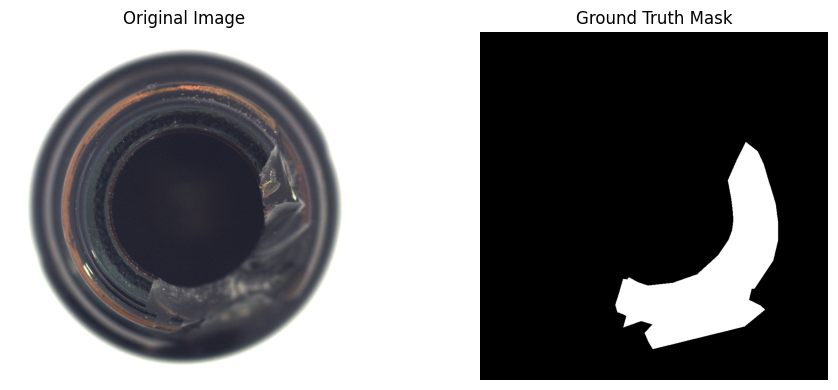

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

original_image = Image.open(test_image_path).convert("RGB")
ground_truth = Image.open(ground_truth_path).convert("L")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

3. 저장된 PatchCore로 단일 이미지 추론

In [16]:
predictions = engine.predict(
    model=model,
    data_path=str(test_image_path),
    ckpt_path=str(checkpoint_path),
    return_predictions=True,
)

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO:lightning_fabric.utilities.rank_zero:Restoring states from the checkpoint path at /content/models/patchcore_bottle.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning_fabric.utilities.rank_zero:Loaded model weights from the checkpoint at /content/models/patchcore_bottle.ckpt


4. 예측 결과 구조 확인

In [17]:
print("Predictions type :", type(predictions))
print("Number of batches:", len(predictions))

prediction_batch = predictions[0]

print("Batch type       :", type(prediction_batch))
print("Available fields :", prediction_batch.keys(include_none=False))

Predictions type : <class 'list'>
Number of batches: 1
Batch type       : <class 'anomalib.data.dataclasses.torch.image.ImageBatch'>
Available fields : ['image', 'anomaly_map', 'pred_score', 'pred_mask', 'pred_label', 'image_path']


5. Image-level Anomaly Score 확인

In [18]:
print("Prediction score:", prediction_batch.pred_score)

Prediction score: tensor([0.9281])


6. Anomaly Map 확인

In [19]:
print("Anomaly map shape:", prediction_batch.anomaly_map.shape)

Anomaly map shape: torch.Size([1, 256, 256])


7. 첫번째 이미지의 Anomaly Map 추출

In [20]:
import numpy as np

anomaly_map = prediction_batch.anomaly_map[0].detach().cpu().numpy()

print("Anomaly map shape:", anomaly_map.shape)
print("Minimum score    :", anomaly_map.min())
print("Maximum score    :", anomaly_map.max())

Anomaly map shape: (256, 256)
Minimum score    : 0.03657469
Maximum score    : 0.8413601


8. Anomaly Map 단독 시각화

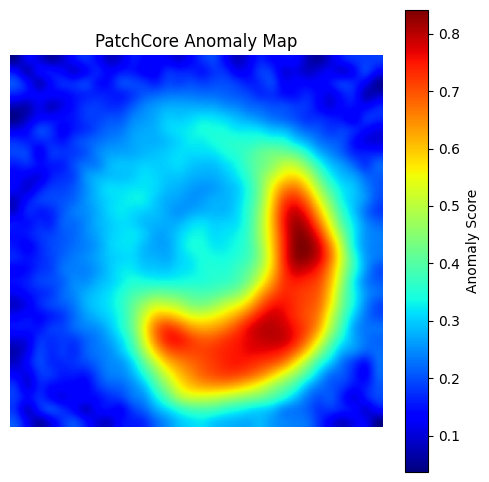

In [21]:
plt.figure(figsize=(6, 6))

plt.imshow(anomaly_map, cmap="jet")
plt.colorbar(label="Anomaly Score")

plt.title("PatchCore Anomaly Map")
plt.axis("off")

plt.show()

9. Anomaly Map을 원본 크기로 맞추기

In [22]:
anomaly_map_image = Image.fromarray(
    anomaly_map.astype(np.float32)
)

anomaly_map_resized = anomaly_map_image.resize(
    original_image.size,
    resample=Image.Resampling.BILINEAR,
)

anomaly_map_resized = np.array(anomaly_map_resized)

print("Original size :", original_image.size)
print("Heatmap shape :", anomaly_map_resized.shape)

Original size : (900, 900)
Heatmap shape : (900, 900)


10. 시각화용 Heatmap 정규화

In [23]:
heatmap_normalized = (
    (anomaly_map_resized - anomaly_map_resized.min())
    / (
        anomaly_map_resized.max()
        - anomaly_map_resized.min()
        + 1e-8
    )
)

11. 원본 이미지 위에 Heatmap Overlay

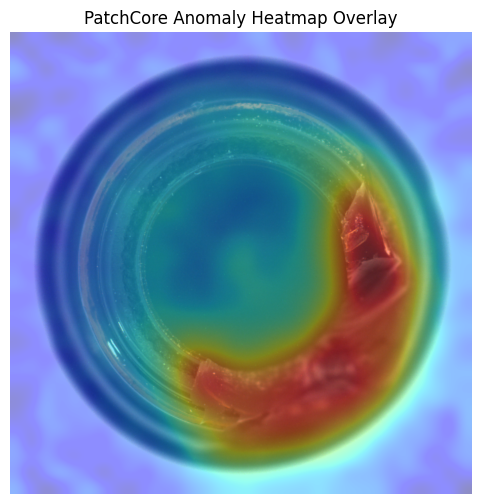

In [24]:
plt.figure(figsize=(6, 6))

plt.imshow(original_image)
plt.imshow(
    heatmap_normalized,
    cmap="jet",
    alpha=0.45,
)

plt.title("PatchCore Anomaly Heatmap Overlay")
plt.axis("off")

plt.show()

12. 최종 4개 결과 비교

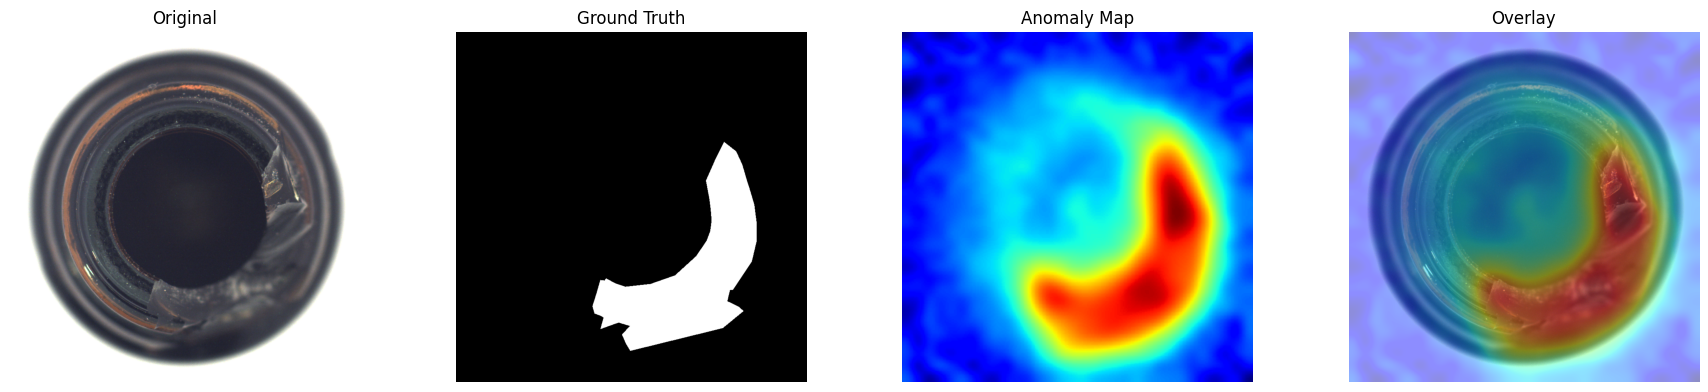

In [25]:
plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(anomaly_map, cmap="jet")
plt.title("Anomaly Map")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(original_image)
plt.imshow(
    heatmap_normalized,
    cmap="jet",
    alpha=0.45,
)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()